#### First Notebook :-   

In [1]:
pip install -q yfinance

In [2]:
pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
!pip install nltk
!pip install vaderSentiment
!pip install pysentiment2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.9 MB/s eta 0:00:00


In [4]:
!pip install newspaper3k
!pip install lxml-html-clean
!pip install transformers torch

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.6 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13540 sha256=210bee44a80d41c40f0dcd3387c205983a62c6f9bfae389e0fa4299a8ed2fc0e
  Stored in directory: /root/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3341 sha256=54d5402f666cf361b27ce3dbdb0276adc18bd7698a72f5f75f31f680275cd8ad
  Stored in directory: /root/.cache/pip/wheels/9f/9f/fb/364871d7426d3cdd4d293dcf7e53d97f16

In [5]:
import re
import os
import sys
import time
import json
import nltk
import logging
import numpy as np
import pandas as pd
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt

# Additional Packages
# Specifically, we are leveraging VADER (Valence Aware Dictionary and Sentiment Reasoner in conjunction with Loughran-Mcdonald (LM) Dictionary for analysis of Long term Financial news and corporate reports)
import pysentiment2 as ps
from newspaper import Article
from transformers import pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from langchain_community.utilities import GoogleSerperAPIWrapper
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

/tmp/ipykernel_38192/3116515081.py:24: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


In [6]:
nltk.download('punkt')
nltk.download("vader_lexicon")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [7]:
PREFIX_QUANT = "quantamental-platform/raw-data/quantitative"
PREFIX_NEWS = "quantamental-platform/raw-data/qualitative"

In [8]:
os.environ["SERPER_API_KEY"] = "1ebc56c48ee3a7dd2bee13d1bb07c0dc6b48fd23"

In [9]:
# Initialize the VADER sentiment intensity analyzer and Loughran-McDonald Token analyzer
analyzer = SentimentIntensityAnalyzer()
lm_analyzer = ps.LM()

In [10]:
# Preliminary Code Example
# Setting up code to fetch news from Yahoo Finance
# links = []
# for ticker in TICKERS:
#   company = yf.Ticker(ticker)

#   # Utilize get_news() property
#   news_article = company.get_news()
#   # Fetching news articles of type "STORY" and storing their links
#   if news_article:
#     links = [n.get("link") for n in news_article if n.get("type")=="STORY"]
# print(f"Links stored successfully")
# print(links)

In [10]:
TICKERS = ["VOO", "QQQ", "SPY", "IWM", "DIA", "GLD", "^VIX"]
START_DATE = "2020-01-01"
END_DATE = "2026-01-01"

SEARCH_MAP = { "VOO": "Vanguard S&P 500 ETF",
              "QQQ": "Invesco QQQ Trust",
               "SPY": "SPDR S&P 500 ETF Trust",
               "IWM": "iShares Russell 2000 ETF",
               "DIA": "SPDR Dow Jones Industrial Average ETF",
               "GLD": "SPDR Gold Shares ETF",
               "^VIX": "CBOE Volatility Index" }

In [11]:
def News_Extractor_System(TICKERS, SEARCH_MAP):
  # Pre-Defined Script to extract available Financial News online
  articles = []
  logger = logging.getLogger(__name__)
  for ticker in TICKERS:
    query = f"{SEARCH_MAP[ticker]} financial news"
    search = GoogleSerperAPIWrapper(type="news",tbs="qdr:d5",serper_api_key=os.environ["SERPER_API_KEY"])
    response = search.results(query)

    news_items = response.get("news", [])
    if not news_items:
      logger.warning(f"{ticker}: No results in last 5 days. Trying 1 week.")
      search = GoogleSerperAPIWrapper(type="news",tbs="qdr:w1",serper_api_key=os.environ["SERPER_API_KEY"])
      response = search.results(query)
      news_items = response.get("news", [])

    for item in news_items:
      articles.append({
              "Ticker": ticker,
              "Title": item.get("title"),
              "Source": item.get("source"),
              "Date": item.get("date"),
              "Link": item.get("link"),
              "Snippet": item.get("snippet")
          })

  articles = pd.DataFrame(articles)
  return articles

In [12]:
news_articles = News_Extractor_System(TICKERS, SEARCH_MAP)
news_articles.head()

,Ticker,Title,Source,Date,Link,Snippet
0,VOO,The Vanguard S&P 500 ETF (VOO) Is the Most Pop...,Yahoo Finance,1 day ago,https://finance.yahoo.com/markets/stocks/artic...,It's hard to beat the market. And more and mor...
1,VOO,Stressing Over Whether Your Index Fund Has Spa...,WSJ,10 hours ago,https://www.wsj.com/finance/stocks/stressing-o...,Being a passive investor means you don't pick ...
2,VOO,Better S&P 500 ETF: VOO vs. SPY,Yahoo Finance,1 day ago,https://finance.yahoo.com/markets/stocks/artic...,The margins between these two iconic stock mar...
3,VOO,1 Vanguard Index Fund Could Turn $450 Per Mont...,The Globe and Mail,10 hours ago,https://www.theglobeandmail.com/investing/mark...,Motley Fool Press Release.
4,VOO,Vanguard S&P 500 ETF (VOO) Stock Price | Quote...,Moomoo,4 days ago,https://www.moomoo.com/stock/VOO-US?chain_id=N...,Track the latest Vanguard S&P 500 ETF (VOO) pr...


In [13]:
%store news_articles

Stored 'news_articles' (DataFrame)


Please use the above approach ----

%store news_articles to store Datasets and transfer across different Notebooks for reuse whenever required.



In [14]:
def Stock_Extractor_System(TICKERS, START_DATE, END_DATE)-> pd.DataFrame:
  df_list = []
  for ticker in TICKERS:
    data = yf.download(ticker, start=START_DATE, end=END_DATE)
    if isinstance(data.columns, pd.MultiIndex):
      data.columns = [col[0] for col in data.columns]
    data = data.reset_index()
    data.rename(columns={data.columns[0]: 'Date'}, inplace=True)
    data['Ticker'] = ticker
    df_list.append(data)

  df = pd.concat(df_list)
  return df

In [15]:
Financial_data = Stock_Extractor_System(TICKERS, START_DATE, END_DATE)
Financial_data.head()

/tmp/ipykernel_38192/1438170455.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_38192/1438170455.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_38192/1438170455.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_38192/1438170455.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3

,Date,Close,High,Low,Open,Volume,Ticker
0,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,VOO
1,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,VOO
2,2020-01-06,270.927155,270.990941,268.193738,268.257524,2777100,VOO
3,2020-01-07,270.180023,270.854257,269.751787,270.444261,2251800,VOO
4,2020-01-08,271.573975,272.712898,270.125268,270.343932,3719500,VOO


In [16]:
%store Financial_data

Stored 'Financial_data' (DataFrame)


In [17]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
news_articles              ->    Ticker                                         


In [18]:
try:
    news_articles
except NameError:
    print("+++++++++++++++++++++++++++++++")
    print("[ERROR] YOU HAVE TO RUN ALL NOTEBOOKS IN THE SETUP FOLDER FIRST. You are missing Setup news_articles.")
    print("+++++++++++++++++++++++++++++++")

In [19]:
try:
    Financial_data
except NameError:
    print("+++++++++++++++++++++++++++++++")
    print("[ERROR] YOU HAVE TO RUN ALL NOTEBOOKS IN THE SETUP FOLDER FIRST. You are missing Setup news_articles.")
    print("+++++++++++++++++++++++++++++++")

In [20]:
if not news_articles.empty:
    print("[OK]")
else:
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("[ERROR] YOUR DATA HAS NOT BEEN REGISTERED. LOOK IN PREVIOUS CELLS TO FIND THE ISSUE.")
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")

[OK]


In [21]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
news_articles              ->    Ticker                                         


Likewise, while working across different notebooks (while having Kernel closed for different notebooks) it becomes possible to share and reuse defined functions over and across notebooks.

Furthermore, in the event of Kernel closedown across different notebooks

Run the following command :

%store -r (Restore)

-r -> Restore variables and Datasets/Dataframes created across notebooks

To list stored resources :-   

%store

#### Weak Supervised (Learning Functions:LF) Heruistics :-      

In [22]:
def extract_article(url):
  try:
    article = Article(url, language='en')
    # To download the article from supplied link
    article.download()
    # To parse the article (i.e extract article content)
    article.parse()

    return article.text
  except Exception:
    return None


In [23]:
def cleaned_text(text):
  text = text.lower()
  text = re.sub('<.*?>', '', text)
  text = re.sub('[^a-zA-Z]', ' ', text)
  text = re.sub(r'\s+', ' ', text)
  return text.strip()

In [24]:
def cast_object_to_string(df):
  for label in df.columns:
    if df.dtypes[label] == "object":
      df[label] = df[label].astype("str").astype("string")

In [25]:
# https://sraf.nd.edu/loughranmcdonald-master-dictionary/?utm_source=chatgpt.com
def Sentiment_Score(text):
  vader_scores = analyzer.polarity_scores(text)
  compound_score = vader_scores['compound']  # Normalizing Vader Scores

  # Loughran-McDonald Analysis
  tokens = lm_analyzer.tokenize(text)
  tokens = [token.lower() for token in tokens]
  # The following Vocabulary set - (297 words in total) is obtained from Loughran-McDonald Master Dictionary 1993-2025: Word dictionary of Quantitative Finance
  uncertainty_vocabulary = {'tentatively', 'speculation', 'recalculation', 'unpredictable', 'risk', 'sometime', 'unproved', 'variances', 'indeterminable', 'nearly', 'reconsiders', 'unforecasted', 'recalculations',
                            'contingencies', 'unusual', 'presumptions', 'unseasonable', 'maybe', 'believing', 'ambiguous', 'suggests', 'unexpectedly', 'vague', 'depend', 'differs', 'predicts', 'anticipating', 'speculative', 'untested', 'vaguely', 'assumptions', 'varying', 'presume', 'indefinitely', 'vaguenesses',
                            'contingency', 'doubt', 'unfamiliar', 'approximate', 'apparently', 'unquantifiable', 'dependency', 'abeyances', 'undocumented', 'appeared', 'differ', 'doubts', 'precaution', 'reinterpretations', 'reinterpretation', 'hinges', 'indefiniteness', 'dependence', 'speculated', 'confusing', 'unplanned', 'unidentifiable', 'volatilities',
                            'deviates', 'vaguest', 'conceivable', 'uncertainly', 'revised', 'uncertainty', 'sometimes', 'fluctuating', 'approximates', 'riskiest', 'unknown', 'ambiguity', 'appears', 'seldomly', 'crossroad', 'doubtful', 'possibilities', 'risks', 'unobservable', 'arbitrary', 'appear', 'differing', 'anomalies', 'fluctuate', 'presumes', 'probably', 'reexamining', 'suddenly', 'riskier', 'unseasonably', 'occasionally', 'presumption', 'vaguer', 'predicting', 'reconsidering', 'variation',
                            'confusingly', 'speculate', 'cautiousness', 'variants', 'randomize', 'speculatively', 'precautionary', 'perhaps', 'approximation', 'reinterprets', 'doubted', 'seldom', 'confusion', 'approximations', 'deviation', 'approximately', 'precautions', 'presumably', 'abeyance', 'improbability', 'random', 'randomizing', 'recalculating', 'recalculated', 'suggesting', 'predictors', 'somewhere', 'undetectable', 'anticipation', 'uncertainties', 'reinterpret', 'unfamiliarity', 'unpredicted', 'fluctuation', 'tentative', 'alterations', 'believes', 'recalculate', 'sporadic', 'unreconciled',
                            'variance', 'clarification', 'variant', 'intangible', 'instabilities', 'possibly', 'assumes', 'hidden', 'suggested', 'uncertain', 'unsettled', 'unidentified', 'believe', 'turbulence', 'unpredictably', 'possibility', 'volatility', 'unwritten', 'cautiously', 'speculates', 'reinterpreting', 'assumed', 'variable', 'undefined', 'apparent', 'susceptibility', 'preliminary', 'almost', 'conditionally', 'preliminarily', 'likelihood', 'randomized', 'speculations', 'nonassessable', 'imprecisions', 'randomizes', 'reassessing', 'conditional', 'unusually', 'contingents', 'presuming', 'roughly', 'exposure', 'reassessed', 'imprecision', 'presumed', 'volatile', 'speculating', 'predictive', 'may', 'unclear', 'unknowns', 'variations', 'predict',
                            'randomness', 'anticipates', 'suggest', 'reassessments', 'vagueness', 'probabilities', 'seems', 'alteration', 'randomly', 'differed', 'approximated', 'arbitrariness', 'reassesses', 'cautious', 'unspecific', 'recalculates', 'deviate', 'reconsider', 'unexpected', 'somewhat', 'ordinarily', 'vary', 'assume', 'predictor', 'possible', 'risky', 'unhedged', 'deviated', 'predictability', 'improbable', 'deviations', 'tending', 'reexamine', 'reassess', 'reinterpreted', 'assumption', 'undesignated', 'unproven', 'inexact', 'unpredictability', 'probability', 'imprecise', 'believed', 'dependencies', 'undeterminable', 'unspecified', 'conceivably', 'intangibles', 'might', 'predictions', 'sporadically', 'unconfirmed', 'anticipated', 'crossroads',
                            'destabilizing', 'probabilistic', 'unquantified', 'anomalous', 'varies', 'variability', 'vagaries', 'could', 'undecided', 'exposures', 'indefinite', 'unforseen', 'unguaranteed', 'anticipations', 'clarifications', 'depending', 'incompleteness', 'riskiness', 'revise', 'reassessment', 'reexamination', 'anomalously', 'anticipate', 'contingently',
                            'appearing', 'arbitrarily', 'deviating', 'fluctuations', 'rumors', 'sudden', 'varied', 'reconsidered', 'assuming', 'predicted', 'fluctuated', 'prediction', 'depends', 'risked', 'variables', 'anomaly', 'undetermined', 'confuses', 'depended', 'indeterminate', 'variably', 'dependent', 'fluctuates', 'pending',
                            'risking', 'inexactness', 'probable', 'ambiguities', 'instability', 'contingent', 'approximating'}

  # uncertainty = sum(word in uncertainty_vocabulary for word in tokens)
  # uncertainty_score = uncertainty / len(tokens)


  if len(tokens) == 0:
    lm_sentiment_score = 0
  else:
    uncertainty = sum(word in uncertainty_vocabulary for word in tokens)
    uncertainty_score = uncertainty / len(tokens)
    lm_scores = lm_analyzer.get_score(tokens)
    positive_scores = lm_scores['Positive'] / len(tokens)
    negative_scores = lm_scores['Negative'] / len(tokens)
    raw_scores = (positive_scores - negative_scores - 0.5*(uncertainty_score))
    lm_sentiment_score =  np.tanh(5 * raw_scores) # Normalization of LM Sentiment Scores within [-1,1] and therefore ensure better correlation with market reactions

  # Applying Weighing
  token_count = len(tokens)
  # For short news headlines
  if token_count < 50:
    w_vader = 0.8
    w_lm = 0.2

  # For long Financial articles-We augment the weights applicable for the Loughran-McDonald (LM) Sentiment analyzer
  elif token_count > 300:
    w_vader = 0.4
    w_lm = 0.6

  else:
    w_vader = 0.6
    w_lm = 0.4

  # Calculating Composite Score :
  # A High Score will indicate Extremely Bullish trend. A very high negative score will be indicative of a Bearish Trend. A neutral sentiment will be inferred for cases when the score=0
  # Hybrid--- Simple Combined Average of both VADER and LM Dictionary based Scores thereby leveraging both context models
  # Standard Grammatical Text rules with Specialized Financial Dictionary Lookup
  Composite_Score = (w_vader*compound_score + w_lm*lm_sentiment_score)
  return pd.Series(Composite_Score*100)


In [26]:
news_articles["Article_Text"] = news_articles['Link'].apply(extract_article)
news_articles = news_articles[(news_articles['Article_Text'].notna())]
news_articles.head()

,Ticker,Title,Source,Date,Link,Snippet,Article_Text
0,VOO,The Vanguard S&P 500 ETF (VOO) Is the Most Pop...,Yahoo Finance,1 day ago,https://finance.yahoo.com/markets/stocks/artic...,It's hard to beat the market. And more and mor...,It's hard to beat the market. And more and mor...
2,VOO,Better S&P 500 ETF: VOO vs. SPY,Yahoo Finance,1 day ago,https://finance.yahoo.com/markets/stocks/artic...,The margins between these two iconic stock mar...,The S&P 500 makes investing simple. The famous...
3,VOO,1 Vanguard Index Fund Could Turn $450 Per Mont...,The Globe and Mail,10 hours ago,https://www.theglobeandmail.com/investing/mark...,Motley Fool Press Release.,Key Points Young adults with median earnings w...
4,VOO,Vanguard S&P 500 ETF (VOO) Stock Price | Quote...,Moomoo,4 days ago,https://www.moomoo.com/stock/VOO-US?chain_id=N...,Track the latest Vanguard S&P 500 ETF (VOO) pr...,Operations too frequent.\n\nTry again later\n\...
6,VOO,Making $100K a Year? Here’s the One Fund That ...,24/7 Wall St.,2 days ago,https://247wallst.com/investing/2026/06/19/mak...,"You open your brokerage app, stare at a dozen ...","Are you ahead, or behind on retirement? SmartA..."


In [27]:
news_articles['Article_Text'] = news_articles['Article_Text'].apply(cleaned_text)
news_articles['Sentiment_Score'] = news_articles['Article_Text'].apply(Sentiment_Score)
news_articles.head()

,Ticker,Title,Source,Date,Link,Snippet,Article_Text,Sentiment_Score
0,VOO,The Vanguard S&P 500 ETF (VOO) Is the Most Pop...,Yahoo Finance,1 day ago,https://finance.yahoo.com/markets/stocks/artic...,It's hard to beat the market. And more and mor...,it s hard to beat the market and more and more...,62.639661
2,VOO,Better S&P 500 ETF: VOO vs. SPY,Yahoo Finance,1 day ago,https://finance.yahoo.com/markets/stocks/artic...,The margins between these two iconic stock mar...,the s p makes investing simple the famous stoc...,62.915606
3,VOO,1 Vanguard Index Fund Could Turn $450 Per Mont...,The Globe and Mail,10 hours ago,https://www.theglobeandmail.com/investing/mark...,Motley Fool Press Release.,key points young adults with median earnings w...,42.857277
4,VOO,Vanguard S&P 500 ETF (VOO) Stock Price | Quote...,Moomoo,4 days ago,https://www.moomoo.com/stock/VOO-US?chain_id=N...,Track the latest Vanguard S&P 500 ETF (VOO) pr...,operations too frequent try again later page n...,-8.196006
6,VOO,Making $100K a Year? Here’s the One Fund That ...,24/7 Wall St.,2 days ago,https://247wallst.com/investing/2026/06/19/mak...,"You open your brokerage app, stare at a dozen ...",are you ahead or behind on retirement smartass...,30.803736


In [28]:
%store news_articles

Stored 'news_articles' (DataFrame)


In [29]:
if not news_articles.empty:
    print("[OK]")
else:
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("[ERROR] YOUR DATA HAS NOT BEEN REGISTERED. LOOK IN PREVIOUS CELLS TO FIND THE ISSUE.")
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")

[OK]


#### Generating Quantamental Data :-

In [30]:
curated_data = pd.merge(news_articles[
    ['Ticker','Article_Text','Sentiment_Score']],
    Financial_data,
    on=['Ticker'],
how='right')

curated_data.head()

,Ticker,Article_Text,Sentiment_Score,Date,Close,High,Low,Open,Volume
0,VOO,it s hard to beat the market and more and more...,62.639661,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400
1,VOO,the s p makes investing simple the famous stoc...,62.915606,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400
2,VOO,key points young adults with median earnings w...,42.857277,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400
3,VOO,operations too frequent try again later page n...,-8.196006,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400
4,VOO,are you ahead or behind on retirement smartass...,30.803736,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400


In [31]:
print(curated_data.isnull().sum())

Ticker             0
Article_Text       0
Sentiment_Score    0
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
dtype: int64


In [32]:
%store curated_data

Stored 'curated_data' (DataFrame)


In [33]:
if not curated_data.empty:
    print("[OK]")
else:
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("[ERROR] YOUR DATA HAS NOT BEEN REGISTERED. LOOK IN PREVIOUS CELLS TO FIND THE ISSUE.")
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")

[OK]


In [34]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
curated_data               ->       Ticker                                      
news_articles              ->    Ticker                                         


#### Second Notebook :-    

### Information Visualization and Feature Engineering :-    

In [35]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
curated_data               ->       Ticker                                      
news_articles              ->    Ticker                                         


In here use

%store -r

In order to restore all previous DataFrames(Datasets) created across notebooks

In [36]:
cast_object_to_string(curated_data)
print(curated_data.dtypes)

Ticker             string[python]
Article_Text       string[python]
Sentiment_Score           float64
Date               datetime64[ns]
Close                     float64
High                      float64
Low                       float64
Open                      float64
Volume                      int64
dtype: object


In [37]:
curated_data['Date'] = pd.to_datetime(curated_data['Date'], utc=True).dt.tz_localize(None)
# THE CRITICAL FIX: Strip timezones and lock exact columns
# Athena chokes on timezone strings and extra columns (like 'Adj Close')

#### Applying Ratings :-

In [38]:
def risk_rating(score):
  """
  Converting Computed Sentiment into Risk Categories
  """
  if score >= 60:
    return "Very Low Risk"
  elif score >= 20:
    return "Low Risk"
  elif score > -20:
    return "Moderate Risk"
  elif score > -60:
    return "High Risk"
  else:
    return "Very High Risk"

In [39]:
def calibrate_ratings(df)-> pd.DataFrame:
  ticker_scores = (df.groupby("Ticker", as_index=False)["Sentiment_Score"].mean())
  ticker_scores['Ratings'] = ticker_scores['Sentiment_Score'].apply(risk_rating)
  df = df.merge(ticker_scores[['Ticker','Ratings']], on='Ticker', how='left')
  return df


In [40]:
# Applying Risk Ratings
curated_data = calibrate_ratings(curated_data)
# Viewing resulting data
curated_data.head(10)

,Ticker,Article_Text,Sentiment_Score,Date,Close,High,Low,Open,Volume,Ratings
0,VOO,it s hard to beat the market and more and more...,62.639661,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
1,VOO,the s p makes investing simple the famous stoc...,62.915606,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
2,VOO,key points young adults with median earnings w...,42.857277,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
3,VOO,operations too frequent try again later page n...,-8.196006,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
4,VOO,are you ahead or behind on retirement smartass...,30.803736,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
5,VOO,key points state street financial select secto...,44.953258,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
6,VOO,representative madeleine dean has filed a new ...,54.749890,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk
7,VOO,it s hard to beat the market and more and more...,62.639661,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk
8,VOO,the s p makes investing simple the famous stoc...,62.915606,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk
9,VOO,key points young adults with median earnings w...,42.857277,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk


In [41]:
curated_data['Ratings'].value_counts()

,count
Ratings,
Low Risk,51272
Moderate Risk,16588


In [42]:
%store curated_data

Stored 'curated_data' (DataFrame)


In [43]:
if not curated_data.empty:
    print("[OK]")
else:
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("[ERROR] YOUR DATA HAS NOT BEEN REGISTERED. LOOK IN PREVIOUS CELLS TO FIND THE ISSUE.")
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")

[OK]


In [44]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
curated_data               ->       Ticker                                      
news_articles              ->    Ticker                                         


#### Quantitative (Volatility) Features :-

##### EDA: Calculating and plot log returns distribution to check for normality

In [53]:
test_normality_df = curated_data.drop_duplicates(subset=['Date', 'Ticker'])
pivot_df = test_normality_df.pivot(index='Date', columns='Ticker')['Close'].dropna()
pivot_df.head()

Ticker,DIA,GLD,IWM,QQQ,SPY,VOO,^VIX
Date,,,,,,,
2020-01-02,256.655823,143.949997,153.069046,208.317551,296.125305,271.902039,12.47
2020-01-03,254.610458,145.860001,152.468933,206.409332,293.883057,269.915802,14.02
2020-01-06,255.197601,147.389999,152.672028,207.739304,295.004089,270.927155,13.85
2020-01-07,254.094788,147.970001,152.164185,207.710419,294.174683,270.180023,13.79
2020-01-08,255.570969,146.860001,152.635147,209.271622,295.742432,271.573975,13.45


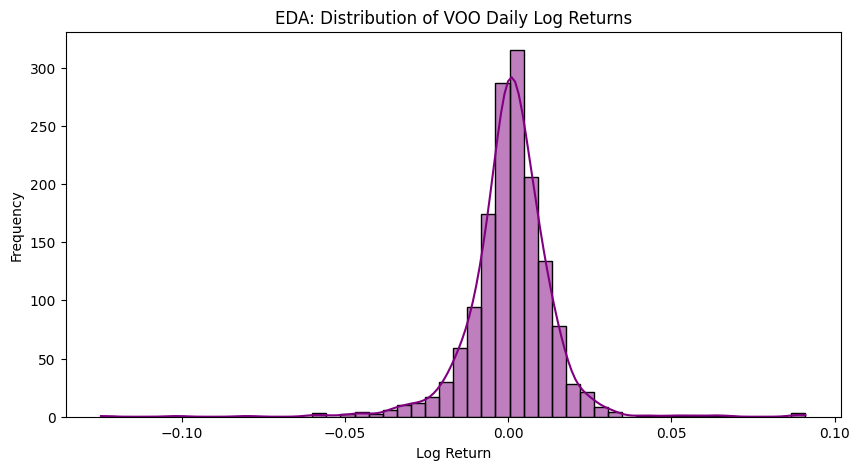

In [54]:
# Calculating and plot log returns distribution to check for normality
voo_log_returns = np.log(pivot_df['VOO'] / pivot_df['VOO'].shift(1)).dropna()
plt.figure(figsize=(10, 5))
sns.histplot(voo_log_returns, bins=50, kde=True, color='purple')
plt.title('EDA: Distribution of VOO Daily Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html

In [57]:
FEATURE_COLS = ['Log_Return', 'EMA_5', 'EMA_20', 'Hist_Vol_5d', 'News_Sentiment_Score']
TARGET_COL   = 'Target_Fwd_Vol_5d'

def Engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Replicateing the exact feature engineering from Eda and Feature Engineering."""
    dfs = []
    for ticker in df['Ticker'].unique():
        t = df[df['Ticker'] == ticker].copy().sort_values('Date')
        t['Log_Return']           = np.log(t['Close'] / t['Close'].shift(1))
        t['EMA_5']                = t['Log_Return'].ewm(span=5,  adjust=False).mean()
        t['EMA_20']               = t['Log_Return'].ewm(span=20, adjust=False).mean()
        t['Hist_Vol_5d']          = t['Log_Return'].rolling(window=5).std()
        t['Target_Fwd_Vol_5d']    = t['Log_Return'].rolling(window=5).std().shift(-5)
        t['News_Sentiment_Score'] = t['Sentiment_Score'] # Clarify: t['News_Sentiment_Score'] = np.log(t['Sentiment_Score']).shift(1) to capture lagged daily sentiment polarity score (St−1 )
        dfs.append(t)
    return pd.concat(dfs).dropna()


In [58]:
compiled_data = Engineer_features(curated_data)
# Viewing resulting dataset
compiled_data.head()

,Ticker,Article_Text,Sentiment_Score,Date,Close,High,Low,Open,Volume,Ratings,Log_Return,EMA_5,EMA_20,Hist_Vol_5d,Target_Fwd_Vol_5d,News_Sentiment_Score
5,VOO,key points state street financial select secto...,44.953258,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk,0.000000,0.000000,0.000000,0.000000,0.003279,44.953258
6,VOO,representative madeleine dean has filed a new ...,54.749890,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk,0.000000,0.000000,0.000000,0.000000,0.003279,54.749890
13,VOO,representative madeleine dean has filed a new ...,54.749890,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk,-0.007332,-0.002444,-0.000698,0.003279,0.000000,54.749890
12,VOO,key points state street financial select secto...,44.953258,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk,0.000000,-0.001629,-0.000632,0.003279,0.000000,44.953258
11,VOO,are you ahead or behind on retirement smartass...,30.803736,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk,0.000000,-0.001086,-0.000572,0.003279,0.001673,30.803736


In [59]:
# Adding mandatory Feature Store columns
compiled_data['EventTime'] = compiled_data['Date'].apply(lambda x: x.timestamp())
compiled_data['RecordIdentifier'] = compiled_data['Ticker'] + "_" + compiled_data['EventTime'].astype(str)

print(f"Feature Engineering Complete. Matrix shape: {compiled_data.shape}")

Feature Engineering Complete. Matrix shape: (67790, 18)


In [65]:
compiled_data.head()

,Ticker,Article_Text,Sentiment_Score,Date,Close,High,Low,Open,Volume,Ratings,Log_Return,EMA_5,EMA_20,Hist_Vol_5d,Target_Fwd_Vol_5d,News_Sentiment_Score,EventTime,RecordIdentifier
5,VOO,key points state street financial select secto...,44.953258,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk,0.000000,0.000000,0.000000,0.000000,0.003279,44.953258,1.577923e+09,VOO_1577923200.0
6,VOO,representative madeleine dean has filed a new ...,54.749890,2020-01-02,271.902039,271.929372,270.006854,270.872447,3142400,Low Risk,0.000000,0.000000,0.000000,0.000000,0.003279,54.749890,1.577923e+09,VOO_1577923200.0
13,VOO,representative madeleine dean has filed a new ...,54.749890,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk,-0.007332,-0.002444,-0.000698,0.003279,0.000000,54.749890,1.578010e+09,VOO_1578009600.0
12,VOO,key points state street financial select secto...,44.953258,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk,0.000000,-0.001629,-0.000632,0.003279,0.000000,44.953258,1.578010e+09,VOO_1578009600.0
11,VOO,are you ahead or behind on retirement smartass...,30.803736,2020-01-03,269.915802,270.936273,268.822452,268.986450,3247900,Low Risk,0.000000,-0.001086,-0.000572,0.003279,0.001673,30.803736,1.578010e+09,VOO_1578009600.0


In [60]:
feature_group_name = "quantamental-risk-features-v2"

# 1. Defining the schema manually for Boto3
feature_definitions = [
    {'FeatureName': 'RecordIdentifier', 'FeatureType': 'String'},
    {'FeatureName': 'Ticker', 'FeatureType': 'String'},
    {'FeatureName': 'EventTime', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Close', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Volume', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Log_Return', 'FeatureType': 'Fractional'},
    {'FeatureName': 'EMA_5', 'FeatureType': 'Fractional'},
    {'FeatureName': 'EMA_20', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Hist_Vol_5d', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Target_Fwd_Vol_5d', 'FeatureType': 'Fractional'},
    {'FeatureName': 'News_Sentiment_Score', 'FeatureType': 'Fractional'}
]

In [61]:
%store compiled_data

Stored 'compiled_data' (DataFrame)


In [62]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
compiled_data              ->       Ticker                                      
curated_data               ->       Ticker                                      
news_articles              ->    Ticker                                         


In [63]:
if not compiled_data.empty:
    print("[OK]")
else:
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("[ERROR] YOUR DATA HAS NOT BEEN REGISTERED. LOOK IN PREVIOUS CELLS TO FIND THE ISSUE.")
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++")

[OK]


In [64]:
%store

Stored variables and their in-db values:
Financial_data             ->            Date       Close        High         Lo
compiled_data              ->       Ticker                                      
curated_data               ->       Ticker                                      
news_articles              ->    Ticker                                         
